In [1]:
%pip install pandas matplotlib scikit-learn

  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Usin

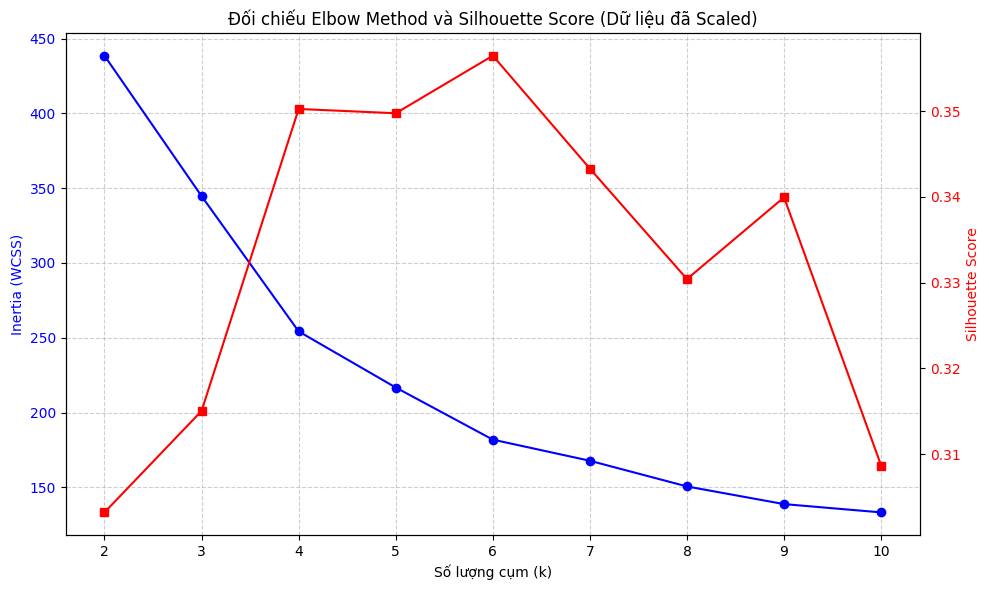

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


df = pd.read_csv('../data/Đã xử lí/scaled_Mall_Customer.csv')


X = df.values 

inertia = []
silhouette_vals = []
k_range = range(2, 11)


for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X)
    
    
    inertia.append(kmeans.inertia_)
    
    
    silhouette_vals.append(silhouette_score(X, cluster_labels))


fig, ax1 = plt.subplots(figsize=(10, 6))


ax1.plot(k_range, inertia, 'bo-', label='Inertia (Elbow)')
ax1.set_xlabel('Số lượng cụm (k)')
ax1.set_ylabel('Inertia (WCSS)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, linestyle='--', alpha=0.6)


ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_vals, 'rs-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Đối chiếu Elbow Method và Silhouette Score (Dữ liệu đã Scaled)')
fig.tight_layout()
plt.show()